In [2]:
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
def load_jsonl(path):
    data = []
    with open(path) as f:
        for line in f:
            data.append(json.loads(line))
    return data


In [5]:
train = load_jsonl("/content/drive/MyDrive/nlp-final/data/processed/squad/train.jsonl")
val   = load_jsonl("/content/drive/MyDrive/nlp-final/data/processed/squad/val.jsonl")
test  = load_jsonl("/content/drive/MyDrive/nlp-final/data/processed/squad/test.jsonl")

print(f"train: {len(train)}")
print(f"val:   {len(val)}")
print(f"test:  {len(test)}")

train: 68536
val:   9155
test:  7880


In [7]:
print(f"Unique train queries:    {len(set(row['query'] for row in train))}")
print(f"Unique train documents:  {len(set(row['document'] for row in train))}")

Unique train queries:    68322
Unique train documents:  14605


In [9]:
query_lengths = [len(row["query"].split()) for row in train]
doc_lengths   = [len(row["document"].split()) for row in train]

print("QUERY LENGTHS")
print(f"avg: {sum(query_lengths)/len(query_lengths):.1f}")
print(f"min: {min(query_lengths)}")
print(f"max: {max(query_lengths)}")

print("\nDOCUMENT LENGTHS")
print(f"avg: {sum(doc_lengths)/len(doc_lengths):.1f}")
print(f"min: {min(doc_lengths)}")
print(f"max: {max(doc_lengths)}")

QUERY LENGTHS
avg: 10.0
min: 1
max: 40

DOCUMENT LENGTHS
avg: 121.8
min: 40
max: 300


In [13]:
print("SAMPLE QUERY-DOCUMENT PAIRS")
for i in range(3):
    print(f"Query:    {train[i]['query']}")
    print(f"Document: {train[i]['document'][:200]}")
    print("-----")

SAMPLE QUERY-DOCUMENT PAIRS
Query:    what three factors do scientists believe are the cause of sexual orientation?
Document: scientists do not know the exact cause of sexual orientation, but they believe that it is caused by a complex interplay of genetic, hormonal, and environmental influences. they favor biologically-base
-----
Query:    what is the favored influence as to the cause of sexual orientation?
Document: scientists do not know the exact cause of sexual orientation, but they believe that it is caused by a complex interplay of genetic, hormonal, and environmental influences. they favor biologically-base
-----
Query:    is there evidence that parenting and/or childhood play a role in determining sexual orientation?
Document: scientists do not know the exact cause of sexual orientation, but they believe that it is caused by a complex interplay of genetic, hormonal, and environmental influences. they favor biologically-base
-----


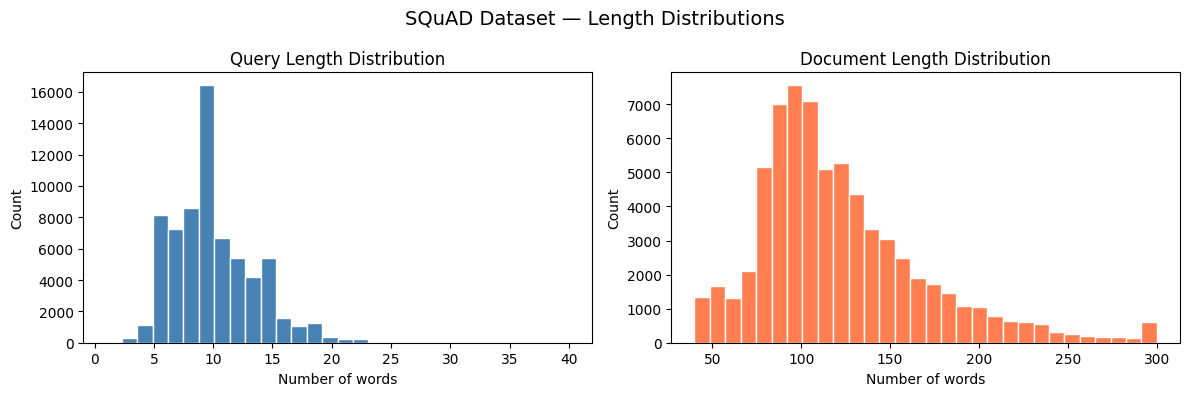

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(query_lengths, bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Query Length Distribution")
axes[0].set_xlabel("Number of words")
axes[0].set_ylabel("Count")

axes[1].hist(doc_lengths, bins=30, color="coral", edgecolor="white")
axes[1].set_title("Document Length Distribution")
axes[1].set_xlabel("Number of words")
axes[1].set_ylabel("Count")

plt.suptitle("SQuAD Dataset — Length Distributions", fontsize=14)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/nlp-final/report/data_lengths.png", dpi=150)
plt.show()

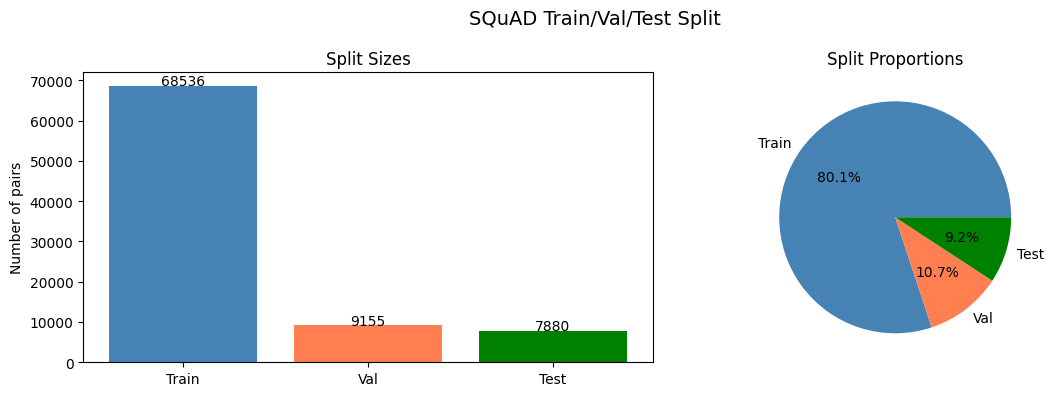

In [15]:
splits = ["Train", "Val", "Test"]
sizes = [len(train), len(val), len(test)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(splits, sizes, color=["steelblue", "coral", "green"])
axes[0].set_title("Split Sizes")
axes[0].set_ylabel("Number of pairs")
for i, v in enumerate(sizes):
    axes[0].text(i, v + 200, str(v), ha="center")

axes[1].pie(sizes, labels=splits, autopct="%1.1f%%", colors=["steelblue", "coral", "green"])
axes[1].set_title("Split Proportions")

plt.suptitle("SQuAD Train/Val/Test Split", fontsize=14)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/nlp-final/report/data_split.png", dpi=150)
plt.show()

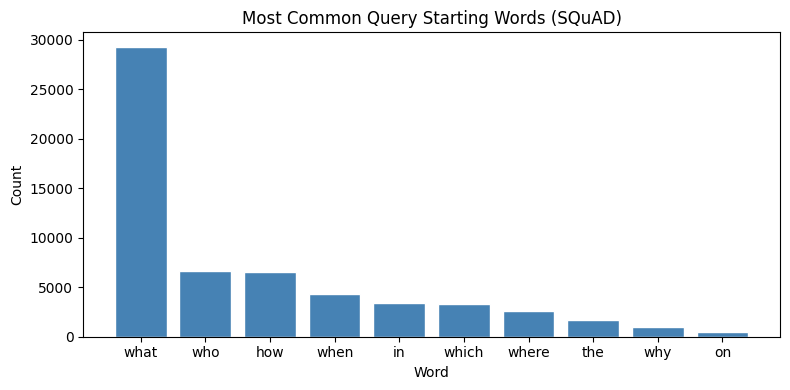

In [16]:
first_words = [row["query"].split()[0].lower() for row in train]
word_counts = Counter(first_words).most_common(10)
words, counts = zip(*word_counts)

plt.figure(figsize=(8, 4))
plt.bar(words, counts, color="steelblue", edgecolor="white")
plt.title("Most Common Query Starting Words (SQuAD)")
plt.xlabel("Word")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/nlp-final/report/query_starts.png", dpi=150)
plt.show()

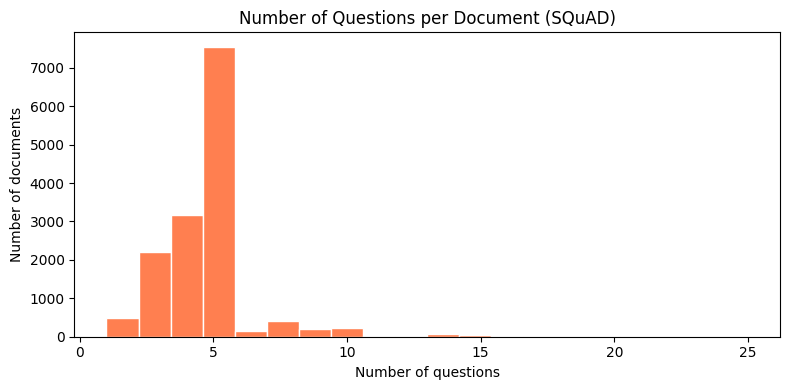

In [17]:
doc_question_counts = Counter(row["document"] for row in train)
counts_per_doc = list(doc_question_counts.values())

plt.figure(figsize=(8, 4))
plt.hist(counts_per_doc, bins=20, color="coral", edgecolor="white")
plt.title("Number of Questions per Document (SQuAD)")
plt.xlabel("Number of questions")
plt.ylabel("Number of documents")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/nlp-final/report/questions_per_doc.png", dpi=150)
plt.show()